# BiLSTM-CNN Baseline ABSA — Vietnamese Student Feedback
Kiến trúc: `Embedding → BiLSTM → CNN (kernel 2,3,4) → MaxPool → FC → Output (11 aspects × 4 classes)`

Baseline tái hiện theo paper gốc để so sánh với mBERT/PhoBERT Multi-task.

- **Label**: 4 class per aspect: `none(0) / positive(1) / neutral(2) / negative(3)`
- **Loss**: `CrossEntropyLoss` — không dùng IGNORE_INDEX
- **Không dùng BERT** — dùng vocabulary tự build + word embedding 300d


In [21]:
!pip install underthesea tensorboardX tqdm -q

## 1. Config

In [22]:
import os, sys, random, unicodedata, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import Adam
from tensorboardX import SummaryWriter
from tqdm.notebook import tqdm, trange
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from collections import Counter
from underthesea import word_tokenize

ON_KAGGLE   = os.path.exists('/kaggle/working')
WORKING_DIR = '/kaggle/working' if ON_KAGGLE else os.getcwd()
print('Environment:', 'Kaggle' if ON_KAGGLE else 'Local')

# ── Data paths (Paper-matched subset: ~5,286 pairs, 7:1:2 split) ─────────
# Subset đã được lọc để khớp phân bố aspect-sentiment của paper gốc
# train_paper      = '/kaggle/input/datasets/conanwinner1/vku-feedback-5k/train_paper.csv'
# validation_paper = '/kaggle/input/datasets/conanwinner1/vku-feedback-5k/validation_paper.csv'
# test_paper       = '/kaggle/input/datasets/conanwinner1/vku-feedback-5k/test_paper.csv'


train1     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train1.csv'
train2     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train2.csv'
train3     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train3.csv'
train4     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train4.csv'
train5     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train5.csv'
train6     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train6.csv'
validation = '/kaggle/input/datasets/conanwinner1/vku-feedback/validation.csv'
test       = '/kaggle/input/datasets/conanwinner1/vku-feedback/test.csv'


OUTPUT_DIR = f'{WORKING_DIR}/bilstm-cnn-acsa'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Aspect Categories (giữ đúng thứ tự như PhoBERT notebook) ─────────────
ASPECT_CATEGORIES = [
    'ky_nang_giang_day',    # 0
    'hanh_vi',              # 1
    'de_xuat',              # 2
    'bai_tap',              # 3
    'chuong_trinh_hoc',     # 4
    'kien_thuc',            # 5
    'kinh_nghiem',          # 6
    'cung_cap_tai_lieu',    # 7
    'thiet_bi_day_hoc',     # 8
    'cham_diem',            # 9
    'noi_chung',            # 10
]
NUM_ASPECTS = len(ASPECT_CATEGORIES)
ASPECT2ID   = {a: i for i, a in enumerate(ASPECT_CATEGORIES)}

# ── Label mapping (4 class per aspect) ───────────────────────────────────
# none=0, positive=1, neutral=2, negative=3
LABEL_MAP = {'none': 0, 'positive': 1, 'neutral': 2, 'negative': 3}
ID2LABEL  = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(LABEL_MAP)

# Mapping từ sentiment string trong CSV → label mới
# CSV: negative=0, neutral=1, positive=2  →  none=0, pos=1, neu=2, neg=3
SENTIMENT_STR_TO_LABEL = {
    'positive': 1,
    'neutral':  2,
    'negative': 3,
}

# ── Model hyperparams (theo paper) ───────────────────────────────────────
EMBEDDING_DIM  = 300
HIDDEN_SIZE    = 128
NUM_FILTERS    = 128
KERNEL_SIZES   = [2, 3, 4]
FC_HIDDEN      = 128
DROPOUT        = 0.6

# ── Training ──────────────────────────────────────────────────────────────
SEED             = 42
MAX_EPOCHS       = 30
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE  = 64
LEARNING_RATE    = 5e-4
WEIGHT_DECAY     = 1e-3
MAX_SEQ_LENGTH   = 128
PATIENCE         = 5

# ── Logging ───────────────────────────────────────────────────────────────
LOG_STEPS  = 50

print(f'Aspects   : {NUM_ASPECTS}')
print(f'Classes   : {NUM_CLASSES} (none/positive/neutral/negative)')
print(f'Output    : {OUTPUT_DIR}')


Environment: Kaggle
Aspects   : 11
Classes   : 4 (none/positive/neutral/negative)
Output    : /kaggle/working/bilstm-cnn-acsa


## 2. Kiểm tra GPU

In [23]:
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu  = torch.cuda.device_count()


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 3. Preprocessing & Vocabulary

In [24]:
def preprocess_text(text):
    """NFC + trim + word segmentation (underthesea)."""
    text = unicodedata.normalize('NFC', str(text).strip())
    text = re.sub(r'^[\s\.\-]+', '', text)
    text = word_tokenize(text, format='text')
    return text.lower()   # lowercase cho BiLSTM


# Test
for s in ['Giảng viên rất nhiệt tình.', '. Thầy/cô tôn trọng sinh viên.']:
    print(f'  {s}  →  {preprocess_text(s)}')

  Giảng viên rất nhiệt tình.  →  giảng_viên rất nhiệt_tình .
  . Thầy/cô tôn trọng sinh viên.  →  thầy / cô tôn_trọng sinh_viên .


## 4. Load Data & Build Vocabulary

In [25]:
from collections import Counter

def load_bilstm_data(df_file):
    """
    Group theo id → mỗi sample:
      - tokens : list[str] (đã preprocess)
      - labels : list[int] length=NUM_ASPECTS, giá trị 0-3
                 0=none, 1=positive, 2=neutral, 3=negative
    """
    df = df_file
    samples = []
    skipped = 0

    for sent_id, group in df.groupby('id'):
        text   = preprocess_text(group.iloc[0]['text'])
        tokens = text.split()

        labels = [0] * NUM_ASPECTS   # mặc định none=0

        for _, row in group.iterrows():
            asp_str = str(row['aspect']).strip()
            sen_str = str(row['sentiment']).strip()

            if asp_str not in ASPECT2ID:
                skipped += 1
                continue
            if sen_str not in SENTIMENT_STR_TO_LABEL:
                skipped += 1
                continue

            asp_idx = ASPECT2ID[asp_str]
            labels[asp_idx] = SENTIMENT_STR_TO_LABEL[sen_str]

        samples.append({'tokens': tokens, 'labels': labels})

    if skipped:
        print(f'  ⚠️  Skipped {skipped} rows')
    return samples


def build_vocab(samples, min_freq=1):
    """Build word2idx từ train set."""
    counter = Counter()
    for s in samples:
        counter.update(s['tokens'])
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            word2idx[word] = len(word2idx)
    return word2idx


def print_stats(samples, split_name):
    print(f'\n  {split_name}: {len(samples)} sentences')
    aspect_counts = [0] * NUM_ASPECTS
    label_counts  = Counter()
    for s in samples:
        for i, lbl in enumerate(s['labels']):
            if lbl != 0:
                aspect_counts[i] += 1
                label_counts[ID2LABEL[lbl]] += 1
    print('  Aspect distribution (non-none):')
    max_cnt = max(aspect_counts) or 1
    for i, cat in enumerate(ASPECT_CATEGORIES):
        bar = '█' * int(20 * aspect_counts[i] / max_cnt)
        print(f'    {i:2d}. {cat:<25s} {aspect_counts[i]:4d}  {bar}')
    print('  Label distribution:', dict(label_counts))


# Load CSVs (Paper-matched subset)
# Load CSVs
df_train1 = pd.read_csv(train1); df_train2 = pd.read_csv(train2)
df_train3 = pd.read_csv(train3); df_train4 = pd.read_csv(train4)
df_train5 = pd.read_csv(train5); df_train6 = pd.read_csv(train6)
df_validation = pd.read_csv(validation)
df_test       = pd.read_csv(test)

train_s = (load_bilstm_data(df_train1) + load_bilstm_data(df_train2) +
           load_bilstm_data(df_train3) + load_bilstm_data(df_train4) +
           load_bilstm_data(df_train5) + load_bilstm_data(df_train6))
dev_s   = load_bilstm_data(df_validation)
test_s  = load_bilstm_data(df_test)


# df_train      = pd.read_csv(train_paper)
# df_validation = pd.read_csv(validation_paper)
# df_test       = pd.read_csv(test_paper)

# train_s = load_bilstm_data(df_train)
# dev_s   = load_bilstm_data(df_validation)
# test_s  = load_bilstm_data(df_test)

# Build vocab từ train set
word2idx = build_vocab(train_s, min_freq=1)
VOCAB_SIZE = len(word2idx)
print(f'Vocab size: {VOCAB_SIZE}')

print_stats(train_s, 'Train')
print_stats(dev_s,   'Dev')
print_stats(test_s,  'Test')


Vocab size: 3997

  Train: 11389 sentences
  Aspect distribution (non-none):
     0. ky_nang_giang_day         4546  ████████████████████
     1. hanh_vi                   4474  ███████████████████
     2. de_xuat                   2044  ████████
     3. bai_tap                   1241  █████
     4. chuong_trinh_hoc           989  ████
     5. kien_thuc                  867  ███
     6. kinh_nghiem                652  ██
     7. cung_cap_tai_lieu          646  ██
     8. thiet_bi_day_hoc           564  ██
     9. cham_diem                  314  █
    10. noi_chung                  546  ██
  Label distribution: {'positive': 8448, 'neutral': 2496, 'negative': 5939}

  Dev: 1575 sentences
  Aspect distribution (non-none):
     0. ky_nang_giang_day          624  ████████████████████
     1. hanh_vi                    608  ███████████████████
     2. de_xuat                    278  ████████
     3. bai_tap                    154  ████
     4. chuong_trinh_hoc           144  ████
     5. kie

## 4.1. Load Pretrained Word Embedding (fastText Vietnamese)

In [26]:
# ── Load Word2VecVN (Tiếng Việt) ──────────────────────────────────────────
# Tải model từ: https://github.com/sonvx/word2vecVN
# Upload file .bin (ví dụ: baomoi.window2.vn.model.bin) lên Kaggle dataset.

import os
from gensim.models import KeyedVectors
import numpy as np

# Đổi tên file ở đây cho đúng với file bạn upload lên Kaggle
WORD2VEC_VN_PATH = '/kaggle/input/models/conanwinner1/w2vec/pytorch/default/1/baomoi.vn.model.bin'

def load_word2vec_embeddings(word2idx, embedding_dim=300, model_path=''):
    """
    Load pre-trained Word2Vec model (gensim) từ file .bin hoặc .vec.
    Hỗ trợ xử lý từ ghép (compound words) tiếng Việt.
    """
    vocab_size = len(word2idx)
    embedding_matrix = np.random.uniform(-0.1, 0.1, (vocab_size, embedding_dim)).astype(np.float32)
    embedding_matrix[0] = 0.0   # <PAD> = zero vector

    try:
        print(f"Loading Word2Vec model from: {model_path} ...")
        if model_path.endswith('.bin'):
            # Load binary format
            w2v_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
        else:
            # Load text format (.vec / .txt)
            w2v_model = KeyedVectors.load_word2vec_format(model_path, binary=False)
            
        # Kiểm tra xem dimension của model có khớp không
        actual_dim = w2v_model.vector_size
        if actual_dim != embedding_dim:
            print(f"⚠️ Cảnh báo: Model dimension ({actual_dim}) khác với cấu hình ({embedding_dim}).")
            print("→ Đang tự động điều chỉnh EMBEDDING_DIM...")
            embedding_matrix = np.random.uniform(-0.1, 0.1, (vocab_size, actual_dim)).astype(np.float32)
            embedding_matrix[0] = 0.0
            embedding_dim = actual_dim
            
        found = 0
        found_subword = 0
        
        for word, idx in word2idx.items():
            if word in ('<PAD>', '<UNK>'):
                continue
                
            # Exact match
            if word in w2v_model:
                embedding_matrix[idx] = w2v_model[word]
                found += 1
            # Xử lý từ ghép tiếng Việt (VD: "giảng_viên" -> trung bình "giảng" và "viên")
            elif '_' in word:
                subwords = word.split('_')
                sub_vecs = [w2v_model[sw] for sw in subwords if sw in w2v_model]
                if sub_vecs:
                    embedding_matrix[idx] = np.mean(sub_vecs, axis=0)
                    found_subword += 1
                    
        total_found = found + found_subword
        coverage = total_found / (vocab_size - 2) * 100
        print(f"  Exact match: {found} words")
        print(f"  Sub-word avg match: {found_subword} words")
        print(f"  Coverage: {total_found}/{vocab_size-2} words ({coverage:.1f}%)")
        print("✓ Successfully loaded pre-trained Word2Vec embeddings")
        
    except Exception as e:
        print(f"⚠️ Error loading Word2Vec: {e}")
        print("⚠️ Using random init embeddings instead.")
        
    return embedding_matrix, embedding_dim

if os.path.exists(WORD2VEC_VN_PATH):
    pretrained_embeddings, EMBEDDING_DIM = load_word2vec_embeddings(word2idx, EMBEDDING_DIM, WORD2VEC_VN_PATH)
else:
    print(f"⚠️ Không tìm thấy file {WORD2VEC_VN_PATH}")
    print("⚠️ Chuyển sang dùng random embeddings.")
    pretrained_embeddings = None


Loading Word2Vec model from: /kaggle/input/models/conanwinner1/w2vec/pytorch/default/1/baomoi.vn.model.bin ...
  Exact match: 3078 words
  Sub-word avg match: 540 words
  Coverage: 3618/3995 words (90.6%)
✓ Successfully loaded pre-trained Word2Vec embeddings


## 5. Dataset & DataLoader

In [27]:
class BiLSTMDataset(Dataset):
    def __init__(self, samples, word2idx, max_len):
        self.samples  = samples
        self.word2idx = word2idx
        self.max_len  = max_len
        self.unk_idx  = word2idx.get('<UNK>', 1)
        self.pad_idx  = word2idx.get('<PAD>', 0)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s      = self.samples[idx]
        tokens = s['tokens']
        ids    = [self.word2idx.get(t, self.unk_idx) for t in tokens]

        # Truncate
        ids = ids[:self.max_len]
        # Pad
        ids = ids + [self.pad_idx] * (self.max_len - len(ids))

        return {
            'input_ids': torch.tensor(ids,          dtype=torch.long),
            'labels':    torch.tensor(s['labels'],  dtype=torch.long),
        }


train_dataset = BiLSTMDataset(train_s, word2idx, MAX_SEQ_LENGTH)
dev_dataset   = BiLSTMDataset(dev_s,   word2idx, MAX_SEQ_LENGTH)
test_dataset  = BiLSTMDataset(test_s,  word2idx, MAX_SEQ_LENGTH)

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset),    batch_size=TRAIN_BATCH_SIZE)
dev_loader   = DataLoader(dev_dataset,   sampler=SequentialSampler(dev_dataset),  batch_size=EVAL_BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  sampler=SequentialSampler(test_dataset), batch_size=EVAL_BATCH_SIZE)

print(f'Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}')


Train: 11389 | Dev: 1575 | Test: 3160


## 6. Model — BiLSTM-CNN

In [28]:
class BiLSTMCNN_ABSA(nn.Module):
    """
    Embedding(300) → BiLSTM(128×2=256) → CNN(k=2,3,4, 128 filters each)
    → GlobalMaxPool → Concat(384) → FC(128) → Output(11×4)
    
    Sử dụng per-aspect weighted CrossEntropyLoss để xử lý class imbalance.
    """
    def __init__(self, vocab_size, embedding_dim=300, hidden_size=128,
                 num_aspects=11, num_classes=4, num_filters=128,
                 kernel_sizes=(2,3,4), fc_hidden=128, dropout=0.5,
                 pretrained_embeddings=None, padding_idx=0,
                 aspect_class_weights=None):
        super().__init__()
        self.num_aspects = num_aspects
        self.num_classes = num_classes

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)

        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.tensor(pretrained_embeddings, dtype=torch.float)
            )
            self.embedding.weight.data[padding_idx] = 0.0  # PAD = zero

        self.bilstm = nn.LSTM(
            input_size=embedding_dim, hidden_size=hidden_size,
            batch_first=True, bidirectional=True
        )
        lstm_out_dim = hidden_size * 2   # 256

        self.convs = nn.ModuleList([
            nn.Conv1d(lstm_out_dim, num_filters, kernel_size=k)
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), fc_hidden)
        self.output  = nn.Linear(fc_hidden, num_aspects * num_classes)

        self.loss_fns = nn.ModuleList()
        if aspect_class_weights is not None:
            for w in aspect_class_weights:
                self.loss_fns.append(nn.CrossEntropyLoss(weight=w))
        else:
            for _ in range(num_aspects):
                self.loss_fns.append(nn.CrossEntropyLoss())

    def forward(self, input_ids, labels=None):
        emb      = self.embedding(input_ids)          # (B, L, 300)
        lstm_out, _ = self.bilstm(emb)                # (B, L, 256)
        x        = lstm_out.transpose(1, 2)           # (B, 256, L)

        pooled = []
        for conv in self.convs:
            c = F.relu(conv(x))                       # (B, 128, L-k+1)
            p = F.max_pool1d(c, c.size(2)).squeeze(2) # (B, 128)
            pooled.append(p)

        x = torch.cat(pooled, dim=1)                  # (B, 384)
        x = self.dropout(x)
        x = F.relu(self.fc(x))                        # (B, 128)
        x = self.dropout(x)
        logits = self.output(x)                       # (B, 44)
        logits = logits.view(-1, self.num_aspects, self.num_classes)  # (B, 11, 4)

        loss = None
        if labels is not None:
            total_loss = 0.0
            for asp_idx in range(self.num_aspects):
                asp_logits = logits[:, asp_idx, :]    # (B, 4)
                asp_labels = labels[:, asp_idx]       # (B,)
                total_loss += self.loss_fns[asp_idx](asp_logits, asp_labels)
            loss = total_loss / self.num_aspects
        return loss, logits


def compute_aspect_class_weights(train_samples, num_aspects=11, num_classes=4):
    """
    Tính class weights cho từng aspect dựa trên inverse frequency.
    """
    counts = np.zeros((num_aspects, num_classes), dtype=np.float64)
    for s in train_samples:
        for i, lbl in enumerate(s['labels']):
            counts[i, lbl] += 1.0

    weights_list = []
    for i in range(num_aspects):
        total = counts[i].sum()
        w = np.zeros(num_classes)
        for c in range(num_classes):
            if counts[i, c] > 0:
                w[c] = np.sqrt(total / (num_classes * counts[i, c]))
            else:
                w[c] = 1.0
        weights_list.append(torch.tensor(w, dtype=torch.float))
        
        asp_name = ASPECT_CATEGORIES[i] if i < len(ASPECT_CATEGORIES) else f"asp_{i}"
        none_pct = counts[i, 0] / total * 100
        print(f"  {asp_name:<25s} none={counts[i,0]:5.0f}({none_pct:5.1f}%) "
              f"pos={counts[i,1]:4.0f} neu={counts[i,2]:4.0f} neg={counts[i,3]:4.0f} "
              f"→ weights=[{w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f}, {w[3]:.2f}]")

    return weights_list


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("\nComputing per-aspect class weights from training data:")
aspect_weights = compute_aspect_class_weights(train_s, NUM_ASPECTS, NUM_CLASSES)
aspect_weights_device = [w.to(device) for w in aspect_weights]

model = BiLSTMCNN_ABSA(
    vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE, num_aspects=NUM_ASPECTS, num_classes=NUM_CLASSES,
    num_filters=NUM_FILTERS, kernel_sizes=KERNEL_SIZES,
    fc_hidden=FC_HIDDEN, dropout=DROPOUT,
    pretrained_embeddings=pretrained_embeddings,
    aspect_class_weights=aspect_weights_device,
)
model.to(device)
if n_gpu > 1:
    model = nn.DataParallel(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✓ BiLSTM-CNN loaded (with per-aspect weighted loss) | Params: {total_params:,}')


Computing per-aspect class weights from training data:
  ky_nang_giang_day         none= 6843( 60.1%) pos=2760 neu= 121 neg=1665 → weights=[0.65, 1.02, 4.85, 1.31]
  hanh_vi                   none= 6915( 60.7%) pos=3510 neu=  51 neg= 913 → weights=[0.64, 0.90, 7.47, 1.77]
  de_xuat                   none= 9345( 82.1%) pos= 326 neu=1475 neg= 243 → weights=[0.55, 2.96, 1.39, 3.42]
  bai_tap                   none=10148( 89.1%) pos= 305 neu= 199 neg= 737 → weights=[0.53, 3.06, 3.78, 1.97]
  chuong_trinh_hoc          none=10400( 91.3%) pos= 132 neu= 185 neg= 672 → weights=[0.52, 4.64, 3.92, 2.06]
  kien_thuc                 none=10522( 92.4%) pos= 636 neu=  33 neg= 198 → weights=[0.52, 2.12, 9.29, 3.79]
  kinh_nghiem               none=10737( 94.3%) pos= 353 neu=  45 neg= 254 → weights=[0.51, 2.84, 7.95, 3.35]
  cung_cap_tai_lieu         none=10743( 94.3%) pos= 185 neu=  85 neg= 376 → weights=[0.51, 3.92, 5.79, 2.75]
  thiet_bi_day_hoc          none=10825( 95.0%) pos=  25 neu=  37 neg= 50

## 7. Training

In [29]:
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    all_gold, all_pred = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            labels    = batch['labels'].to(device)

            loss, logits = model(input_ids, labels)
            if n_gpu > 1: loss = loss.mean()
            total_loss += loss.item()

            pred = logits.argmax(dim=-1).cpu().numpy()   # (B, 11)
            gold = labels.cpu().numpy()                  # (B, 11)
            all_gold.append(gold)
            all_pred.append(pred)

    all_gold = np.vstack(all_gold)   # (N, 11)
    all_pred = np.vstack(all_pred)

    # Aspect Detection: pred!=0 → aspect present
    asp_gold = (all_gold != 0).astype(int)
    asp_pred = (all_pred != 0).astype(int)
    asp_f1_micro = f1_score(asp_gold, asp_pred, average='micro', zero_division=0)
    asp_f1_macro = f1_score(asp_gold, asp_pred, average='macro', zero_division=0)

    # Aspect-Sentiment: chỉ tính ở vị trí gold != 0
    mask = all_gold != 0
    sent_gold = all_gold[mask].tolist()
    sent_pred = all_pred[mask].tolist()
    sent_f1_macro = f1_score(sent_gold, sent_pred, average='macro',
                             labels=[1,2,3], zero_division=0)
    sent_f1_micro = f1_score(sent_gold, sent_pred, average='micro',
                             labels=[1,2,3], zero_division=0)

    return {
        'loss':          total_loss / len(loader),
        'asp_f1_micro':  asp_f1_micro,
        'asp_f1_macro':  asp_f1_macro,
        'sent_f1_micro': sent_f1_micro,
        'sent_f1_macro': sent_f1_macro,
        'all_gold':      all_gold,
        'all_pred':      all_pred,
        'sent_gold':     sent_gold,
        'sent_pred':     sent_pred,
    }


In [30]:
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)
tb_writer = SummaryWriter(log_dir=OUTPUT_DIR)

history = {
    'epoch': [], 'train_loss': [], 'val_loss': [],
    'val_asp_f1_micro': [], 'val_asp_f1_macro': [],
    'val_sent_f1_micro': [], 'val_sent_f1_macro': [],
}

best_val_f1    = 0.0
patience_count = 0
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_model.pt')
global_step    = 0

for epoch in trange(MAX_EPOCHS, desc='Epoch'):
    model.train()
    epoch_loss, epoch_steps = 0.0, 0

    for batch in tqdm(train_loader, desc=f'Train E{epoch+1}', leave=False):
        input_ids = batch['input_ids'].to(device)
        labels    = batch['labels'].to(device)

        loss, _ = model(input_ids, labels)
        if n_gpu > 1: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad()

        epoch_loss  += loss.item()
        epoch_steps += 1
        global_step += 1

        if global_step % LOG_STEPS == 0:
            tb_writer.add_scalar('train_loss', loss.item(), global_step)

    val_metrics = evaluate_model(model, dev_loader)
    avg_train   = epoch_loss / epoch_steps

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_metrics['loss'])
    history['val_asp_f1_micro'].append(val_metrics['asp_f1_micro'])
    history['val_asp_f1_macro'].append(val_metrics['asp_f1_macro'])
    history['val_sent_f1_micro'].append(val_metrics['sent_f1_micro'])
    history['val_sent_f1_macro'].append(val_metrics['sent_f1_macro'])

    tb_writer.add_scalar('val_loss',         val_metrics['loss'],          global_step)
    tb_writer.add_scalar('val_asp_f1_micro', val_metrics['asp_f1_micro'],  global_step)
    tb_writer.add_scalar('val_sent_f1_macro',val_metrics['sent_f1_macro'], global_step)

    print(f"[Epoch {epoch+1}] train_loss={avg_train:.4f} | val_loss={val_metrics['loss']:.4f} | "
          f"asp_f1_micro={val_metrics['asp_f1_micro']:.4f} | sent_f1_macro={val_metrics['sent_f1_macro']:.4f}")

    # Early stopping theo asp_f1_micro (aspect detection)
    scheduler.step(val_metrics['asp_f1_micro'])

    if val_metrics['asp_f1_micro'] > best_val_f1:
        best_val_f1 = val_metrics['asp_f1_micro']
        patience_count = 0
        m = model.module if hasattr(model, 'module') else model
        torch.save(m.state_dict(), best_ckpt_path)
        print(f'  ✓ Best model saved (asp_f1_micro={best_val_f1:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

tb_writer.close()
m = model.module if hasattr(model, 'module') else model
torch.save(m.state_dict(), os.path.join(OUTPUT_DIR, 'model_final.pt'))
print(f'\n✓ Training done. Best asp_f1_micro={best_val_f1:.4f}')


Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Train E1:   0%|          | 0/356 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

[Epoch 1] train_loss=0.7668 | val_loss=0.5659 | asp_f1_micro=0.7006 | sent_f1_macro=0.6530
  ✓ Best model saved (asp_f1_micro=0.7006)


...

[Epoch 14] train_loss=0.3723 | val_loss=0.3712 | asp_f1_micro=0.8104 | sent_f1_macro=0.7524
  No improvement (4/5)


Train E15:   0%|          | 0/356 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

[Epoch 15] train_loss=0.3682 | val_loss=0.3767 | asp_f1_micro=0.8123 | sent_f1_macro=0.7524
  No improvement (5/5)
  Early stopping at epoch 15

✓ Training done. Best asp_f1_micro=0.8194


## 8. Evaluation

In [31]:
print('=== Dev ===')
dev_metrics = evaluate_model(model, dev_loader)
print(f"asp_f1_micro={dev_metrics['asp_f1_micro']:.4f} | asp_f1_macro={dev_metrics['asp_f1_macro']:.4f}")
print(f"sent_f1_micro={dev_metrics['sent_f1_micro']:.4f} | sent_f1_macro={dev_metrics['sent_f1_macro']:.4f}")

print('\n=== Test ===')
test_metrics = evaluate_model(model, test_loader)
print(f"asp_f1_micro={test_metrics['asp_f1_micro']:.4f} | asp_f1_macro={test_metrics['asp_f1_macro']:.4f}")
print(f"sent_f1_micro={test_metrics['sent_f1_micro']:.4f} | sent_f1_macro={test_metrics['sent_f1_macro']:.4f}")

print('\nPer-class Sentiment (Test, bỏ none):')
print(classification_report(
    test_metrics['sent_gold'], test_metrics['sent_pred'],
    labels=[1,2,3], target_names=['positive','neutral','negative'], zero_division=0))


=== Dev ===


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


asp_f1_micro=0.8123 | asp_f1_macro=0.7614
sent_f1_micro=0.8032 | sent_f1_macro=0.7524

=== Test ===


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


asp_f1_micro=0.8179 | asp_f1_macro=0.7586
sent_f1_micro=0.8022 | sent_f1_macro=0.7552

Per-class Sentiment (Test, bỏ none):
              precision    recall  f1-score   support

    positive       0.95      0.83      0.88      2344
     neutral       0.65      0.60      0.62       691
    negative       0.89      0.67      0.76      1629

   micro avg       0.88      0.74      0.80      4664
   macro avg       0.83      0.70      0.76      4664
weighted avg       0.88      0.74      0.80      4664



## 📊 Paper-style Evaluation (Bảng 3 & Bảng 4)

Đánh giá theo đúng format paper gốc:
- **Bảng 3**: Phát hiện khía cạnh (Aspect Detection) — binary none vs non-none
- **Bảng 4**: Phát hiện khía cạnh + cảm xúc (Aspect-Sentiment Joint) — exact match

In [32]:
# ══════════════════════════════════════════════════════════════════════════
# Paper-style Evaluation: Bảng 3 & Bảng 4
# ══════════════════════════════════════════════════════════════════════════

all_gold = test_metrics['all_gold']   # (N, 11)  — giá trị 0-3
all_pred = test_metrics['all_pred']   # (N, 11)

# ──────────────────────────────────────────────────────────────────────────
# Bảng 3: Phát hiện khía cạnh (Aspect Detection)
# Binary: none (0) vs non-none (1,2,3)
# ──────────────────────────────────────────────────────────────────────────
gold_bin = (all_gold != 0).astype(int).flatten()
pred_bin = (all_pred != 0).astype(int).flatten()

tp_ad = int(((gold_bin == 1) & (pred_bin == 1)).sum())
fp_ad = int(((gold_bin == 0) & (pred_bin == 1)).sum())
fn_ad = int(((gold_bin == 1) & (pred_bin == 0)).sum())

p_ad  = tp_ad / (tp_ad + fp_ad) * 100 if (tp_ad + fp_ad) > 0 else 0
r_ad  = tp_ad / (tp_ad + fn_ad) * 100 if (tp_ad + fn_ad) > 0 else 0
f1_ad = 2 * p_ad * r_ad / (p_ad + r_ad) if (p_ad + r_ad) > 0 else 0

print("=" * 72)
print("Bảng 3. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh")
print("         trên tập kiểm tra")
print("=" * 72)
print(f"{'Phương pháp':<15s} {'Độ chính xác (%)':>18s} {'Độ phủ (%)':>14s} {'Chỉ số F1 (%)':>16s}")
print("-" * 72)
print(f"{'BiLSTM-CNN':<15s} {p_ad:>18.2f} {r_ad:>14.2f} {f1_ad:>16.2f}")
print()

# ──────────────────────────────────────────────────────────────────────────
# Bảng 4: Phát hiện khía cạnh VÀ trạng thái cảm xúc tương ứng
# (Aspect-Sentiment Joint Evaluation)
#
# TP: gold != 0 AND pred == gold  (đúng aspect + đúng sentiment)
# FP: pred != 0 AND pred != gold  (dự đoán sai: sai aspect hoặc sai sentiment)
# FN: gold != 0 AND pred != gold  (bỏ sót hoặc sai sentiment)
# ──────────────────────────────────────────────────────────────────────────
tp_as = 0
fp_as = 0
fn_as = 0

for i in range(all_gold.shape[0]):
    for j in range(all_gold.shape[1]):
        y = int(all_gold[i, j])
        p = int(all_pred[i, j])
        
        if y != 0 and p == y:
            tp_as += 1          # Đúng aspect + đúng sentiment
        if y != 0 and p != y:
            fn_as += 1          # Bỏ sót (hoặc sai sentiment)
        if p != 0 and p != y:
            fp_as += 1          # Dự đoán sai

p_as  = tp_as / (tp_as + fp_as) * 100 if (tp_as + fp_as) > 0 else 0
r_as  = tp_as / (tp_as + fn_as) * 100 if (tp_as + fn_as) > 0 else 0
f1_as = 2 * p_as * r_as / (p_as + r_as) if (p_as + r_as) > 0 else 0

print("=" * 72)
print("Bảng 4. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh")
print("         và trạng thái cảm xúc tương ứng trên tập kiểm tra")
print("=" * 72)
print(f"{'Phương pháp':<15s} {'Độ chính xác (%)':>18s} {'Độ phủ (%)':>14s} {'Chỉ số F1 (%)':>16s}")
print("-" * 72)
print(f"{'BiLSTM-CNN':<15s} {p_as:>18.2f} {r_as:>14.2f} {f1_as:>16.2f}")
print()

# ──────────────────────────────────────────────────────────────────────────
# Chi tiết per-aspect (Bảng 3 style)
# ──────────────────────────────────────────────────────────────────────────
print("=" * 72)
print("Chi tiết phát hiện khía cạnh TỪNG aspect (Aspect Detection)")
print("=" * 72)
print(f"{'Khía cạnh':<25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}")
print("-" * 72)

for idx, asp_name in enumerate(ASPECT_CATEGORIES):
    g = (all_gold[:, idx] != 0).astype(int)
    p = (all_pred[:, idx] != 0).astype(int)
    tp = int(((g == 1) & (p == 1)).sum())
    fp = int(((g == 0) & (p == 1)).sum())
    fn = int(((g == 1) & (p == 0)).sum())
    support = int(g.sum())
    
    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"{asp_name:<25s} {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}% {support:>10d}")

print("-" * 72)
print(f"{'Micro-average':<25s} {p_ad:>9.2f}% {r_ad:>9.2f}% {f1_ad:>9.2f}%")
print()

# ──────────────────────────────────────────────────────────────────────────
# Chi tiết per-aspect (Bảng 4 style)
# ──────────────────────────────────────────────────────────────────────────
print("=" * 72)
print("Chi tiết phát hiện khía cạnh + cảm xúc TỪNG aspect")
print("=" * 72)
print(f"{'Khía cạnh':<25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>10s}")
print("-" * 72)

for idx, asp_name in enumerate(ASPECT_CATEGORIES):
    g_col = all_gold[:, idx]
    p_col = all_pred[:, idx]
    
    tp = int(((g_col != 0) & (p_col == g_col)).sum())
    fn = int(((g_col != 0) & (p_col != g_col)).sum())
    fp = int(((p_col != 0) & (p_col != g_col)).sum())
    support = int((g_col != 0).sum())
    
    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"{asp_name:<25s} {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}% {support:>10d}")

print("-" * 72)
print(f"{'Micro-average':<25s} {p_as:>9.2f}% {r_as:>9.2f}% {f1_as:>9.2f}%")

# ──────────────────────────────────────────────────────────────────────────
# So sánh với kết quả paper gốc
# ──────────────────────────────────────────────────────────────────────────
print()
print("=" * 72)
print("So sánh với kết quả paper gốc")
print("=" * 72)
print(f"{'':25s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 72)
print(f"{'Bảng 3 - Paper':<25s} {'78.78':>10s} {'79.08':>10s} {'78.93':>10s}")
print(f"{'Bảng 3 - Ours':<25s} {p_ad:>9.2f}% {r_ad:>9.2f}% {f1_ad:>9.2f}%")
print()
print(f"{'Bảng 4 - Paper':<25s} {'73.64':>10s} {'73.93':>10s} {'73.78':>10s}")
print(f"{'Bảng 4 - Ours':<25s} {p_as:>9.2f}% {r_as:>9.2f}% {f1_as:>9.2f}%")


Bảng 3. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh
         trên tập kiểm tra
Phương pháp       Độ chính xác (%)     Độ phủ (%)    Chỉ số F1 (%)
------------------------------------------------------------------------
BiLSTM-CNN                   80.14          83.51            81.79

Bảng 4. Kết quả thí nghiệm cho bài toán phát hiện khía cạnh
         và trạng thái cảm xúc tương ứng trên tập kiểm tra
Phương pháp       Độ chính xác (%)     Độ phủ (%)    Chỉ số F1 (%)
------------------------------------------------------------------------
BiLSTM-CNN                   70.64          73.61            72.09

Chi tiết phát hiện khía cạnh TỪNG aspect (Aspect Detection)
Khía cạnh                  Precision     Recall         F1    Support
------------------------------------------------------------------------
ky_nang_giang_day             85.90%     85.31%     85.61%       1314
hanh_vi                       80.87%     93.71%     86.82%       1209
de_xuat                       84.51

## 9. Visualization

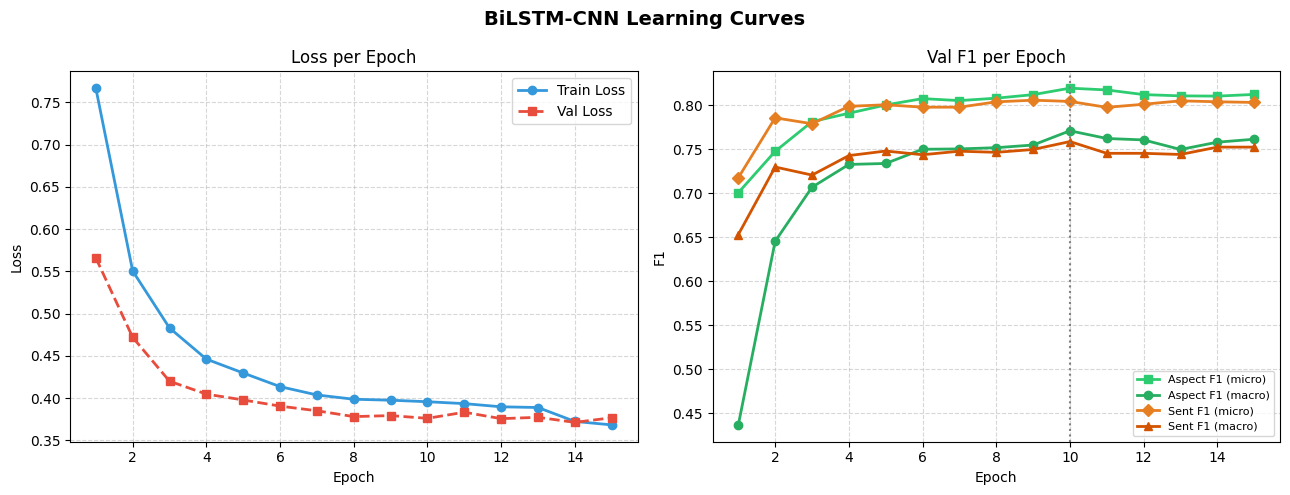

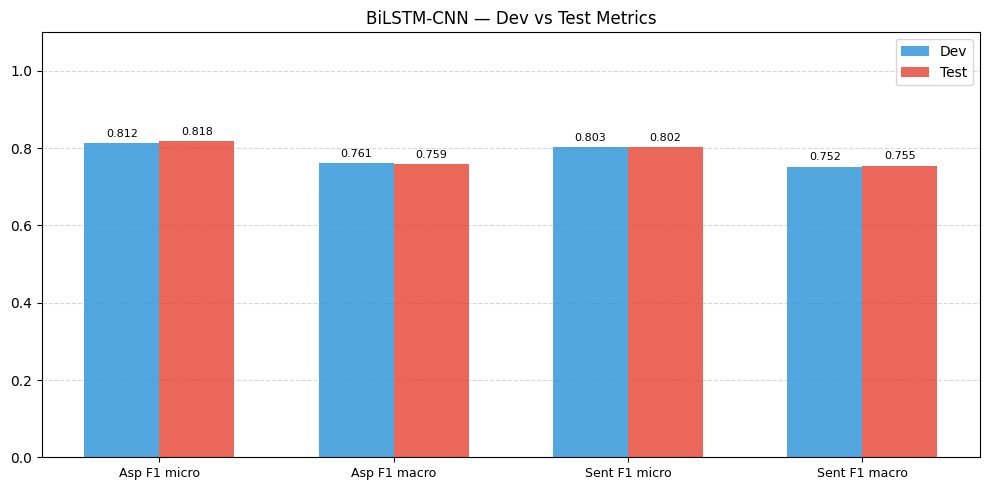

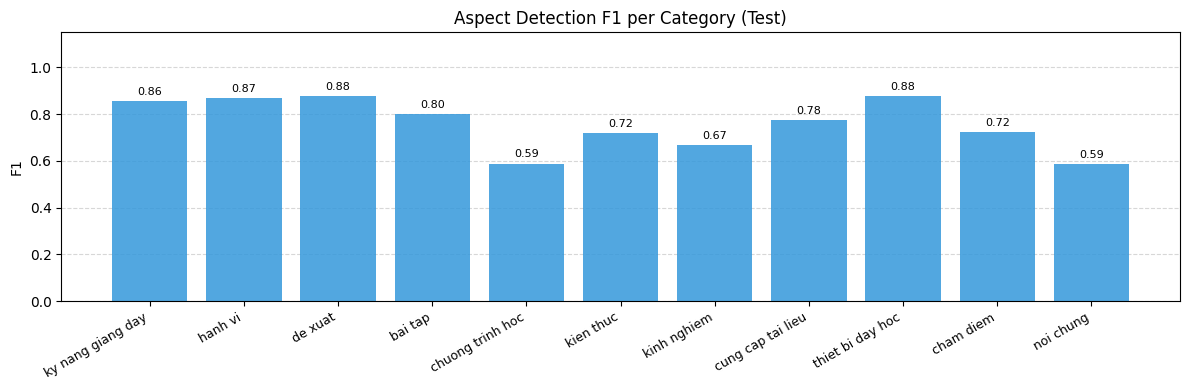

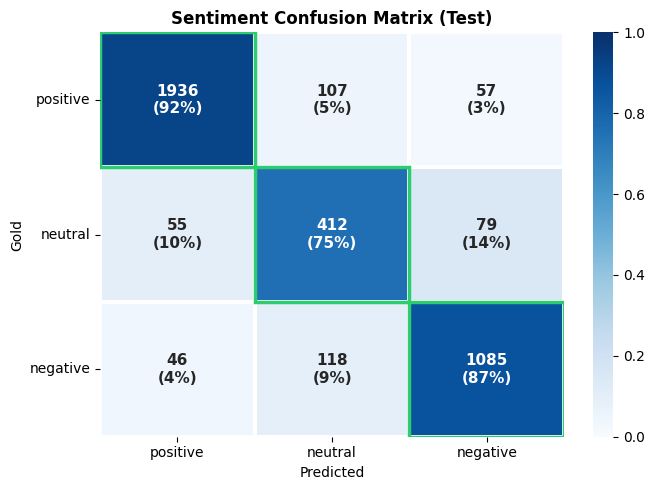

In [33]:
from sklearn.metrics import f1_score as sk_f1

# ── 1. Learning curves ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BiLSTM-CNN Learning Curves', fontsize=14, fontweight='bold')

epochs = history['epoch']
ax1.plot(epochs, history['train_loss'], 'o-', color='#3498db', label='Train Loss', lw=2)
ax1.plot(epochs, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss per Epoch')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)

ax2.plot(epochs, history['val_asp_f1_micro'],   's-', color='#2ecc71', lw=2, label='Aspect F1 (micro)')
ax2.plot(epochs, history['val_asp_f1_macro'],   'o-', color='#27ae60', lw=2, label='Aspect F1 (macro)')
ax2.plot(epochs, history['val_sent_f1_micro'],  'D-', color='#e67e22', lw=2, label='Sent F1 (micro)')
ax2.plot(epochs, history['val_sent_f1_macro'],  '^-', color='#d35400', lw=2, label='Sent F1 (macro)')
best_epoch = epochs[history['val_asp_f1_micro'].index(max(history['val_asp_f1_micro']))]
ax2.axvline(best_epoch, color='gray', linestyle=':', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1'); ax2.set_title('Val F1 per Epoch')
ax2.legend(fontsize=8); ax2.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Dev vs Test bar chart ──────────────────────────────────────────────
metrics_compare = {
    'Asp F1 micro': (dev_metrics['asp_f1_micro'],  test_metrics['asp_f1_micro']),
    'Asp F1 macro': (dev_metrics['asp_f1_macro'],  test_metrics['asp_f1_macro']),
    'Sent F1 micro':(dev_metrics['sent_f1_micro'], test_metrics['sent_f1_micro']),
    'Sent F1 macro':(dev_metrics['sent_f1_macro'], test_metrics['sent_f1_macro']),
}
x = np.arange(len(metrics_compare)); width = 0.32
fig, ax = plt.subplots(figsize=(10, 5))
for i, (split, col) in enumerate([('Dev','#3498db'),('Test','#e74c3c')]):
    vals = [v[i] for v in metrics_compare.values()]
    bars = ax.bar(x + (i-0.5)*width, vals, width, label=split, color=col, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.set_xticks(x); ax.set_xticklabels(list(metrics_compare.keys()), fontsize=9)
ax.set_ylim(0, 1.1); ax.set_title('BiLSTM-CNN — Dev vs Test Metrics')
ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── 3. Per-category Aspect F1 (Test) ─────────────────────────────────────
all_gold = test_metrics['all_gold']
all_pred = test_metrics['all_pred']
per_cat_f1 = [
    sk_f1((all_gold[:,i]!=0).astype(int), (all_pred[:,i]!=0).astype(int), zero_division=0)
    for i in range(NUM_ASPECTS)
]
short_labels = [c.replace('_',' ') for c in ASPECT_CATEGORIES]
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(short_labels, per_cat_f1, color='#3498db', alpha=0.85)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
ax.set_ylim(0, 1.15); ax.set_ylabel('F1')
ax.set_title('Aspect Detection F1 per Category (Test)')
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# ── 4. Sentiment confusion matrix (Test, bỏ none) ────────────────────────
cm      = confusion_matrix(test_metrics['sent_gold'], test_metrics['sent_pred'], labels=[1,2,3])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)] for i in range(3)])
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=annots, fmt='', cmap='Blues', ax=ax,
            xticklabels=['positive','neutral','negative'],
            yticklabels=['positive','neutral','negative'],
            vmin=0, vmax=1, linewidths=1.5, linecolor='white',
            annot_kws={'size':11,'weight':'bold'})
for i in range(3):
    ax.add_patch(plt.Rectangle((i,i),1,1,fill=False,edgecolor='#2ecc71',lw=2.5))
ax.set_title('Sentiment Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gold'); ax.set_xlabel('Predicted')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()


## 10. Inference

In [34]:
def predict(text, model, word2idx, threshold_none=0.5):
    """
    Predict aspects và sentiment cho 1 câu.
    threshold_none: nếu max_prob(non-none) < threshold thì bỏ qua aspect đó.
    """
    model.eval()
    tokens = preprocess_text(text).split()
    unk    = word2idx.get('<UNK>', 1)
    pad    = word2idx.get('<PAD>', 0)
    ids    = [word2idx.get(t, unk) for t in tokens][:MAX_SEQ_LENGTH]
    ids    = ids + [pad] * (MAX_SEQ_LENGTH - len(ids))

    with torch.no_grad():
        input_ids = torch.tensor([ids], dtype=torch.long).to(device)
        _, logits = model(input_ids)                          # (1, 11, 4)
        probs     = F.softmax(logits, dim=-1).squeeze(0)      # (11, 4)
        pred      = logits.argmax(dim=-1).squeeze(0).cpu()    # (11,)

    results = []
    for i, cat in enumerate(ASPECT_CATEGORIES):
        label_id = pred[i].item()
        if label_id == 0:
            continue
        confidence = probs[i, label_id].item()
        results.append({
            'category':   cat,
            'sentiment':  ID2LABEL[label_id],
            'confidence': round(confidence, 3),
        })
    return results


test_sentences = [
    'Thầy dạy rất hay nhưng phòng học quá nóng.',
    'Giảng viên nhiệt tình, tài liệu đầy đủ.',
    'Bài kiểm tra quá khó và không công bằng.',
]
for sent in test_sentences:
    result = predict(sent, model, word2idx)
    print(f'Input : {sent}')
    for r in result:
        print(f'  → [{r["category"]}] {r["sentiment"]} (conf={r["confidence"]})')
    print()


Input : Thầy dạy rất hay nhưng phòng học quá nóng.
  → [ky_nang_giang_day] negative (conf=0.506)
  → [thiet_bi_day_hoc] negative (conf=0.696)

Input : Giảng viên nhiệt tình, tài liệu đầy đủ.
  → [hanh_vi] positive (conf=0.965)
  → [cung_cap_tai_lieu] positive (conf=0.963)

Input : Bài kiểm tra quá khó và không công bằng.
  → [bai_tap] negative (conf=0.908)
  → [cham_diem] negative (conf=0.67)

